In [ ]:
from utils import *
from matplotlib import pyplot as plt

# --- Simple NN (model id 6) dependencies ---
from sklearn.pipeline import Pipeline              # <<< ADDED
from sklearn.preprocessing import StandardScaler   # <<< ADDED
from sklearn.neural_network import MLPClassifier   # <<< ADDED


In [11]:
which_dataset = 2    # 'iris = 0', 'crop = 1', 'adult = 2', 'breast = 3', 'nursery = 4', 'mushroom = 5'
which_model = 1      # 'Decision_Tree = 0', 'Logistic_Regression = 1', 'Multinomial_Naive_Bayes = 2', 'K_Nearest_Neeighbor = 3', 'Random_Forest = 4', 'Multilayer_Perceptron = 5'
explanation_tool = 0 # 'Lime = 0', 'Shap = 1'
how_many_sets = 10 # This is the number of auxiliary datasets to experiment on. Lower the number for lowering the runtime.
sample_set_sizes = [3] # (list of n values from the paper) Size of auxiliary dataset (per class) in a list format
nfe = [1,3,5,7,9,11] # (list of k values from the paper) Number of features explored in a list format
query_limit = [100,250,500,1000] # (list of Q values from the paper) Number of queries allowed for traversal

In [12]:
## IMPORTANT: Adult Income dataset can have difficulties with creating unique sample sets. 
## Either re-run this script until it does not give error in the first 10 (default) sample sets.
## Or reduce the number in how_many_sets.

print('This will take a long time! (Approx: 1 hour (M1 Macbook Air))')
## Shorten nfe for shorter runtime

accuracies, rtest_sims, samples_mega, other_args = run_attack_auto(which_dataset, which_model, explanation_tool, how_many_sets, sample_set_sizes, nfe, query_limit, False)

This will take a long time! (Approx: 1 hour (M1 Macbook Air))
Train results
[[17251  1255]
 [ 2815  3099]]
              precision    recall  f1-score   support

           0       0.86      0.93      0.89     18506
           1       0.71      0.52      0.60      5914

    accuracy                           0.83     24420
   macro avg       0.79      0.73      0.75     24420
weighted avg       0.82      0.83      0.82     24420

Test results
[[3409  278]
 [ 570  627]]
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      3687
           1       0.69      0.52      0.60      1197

    accuracy                           0.83      4884
   macro avg       0.77      0.72      0.74      4884
weighted avg       0.82      0.83      0.82      4884

Model test accuracy:  0.8264 

Dataset:   Adult Income
ML Model:  Logistic Regression
LIME is the explanation tool currently in use

Lower bounds:  [26, 63, 126, 251]  Upper bounds:  [126, 313, 626, 

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0

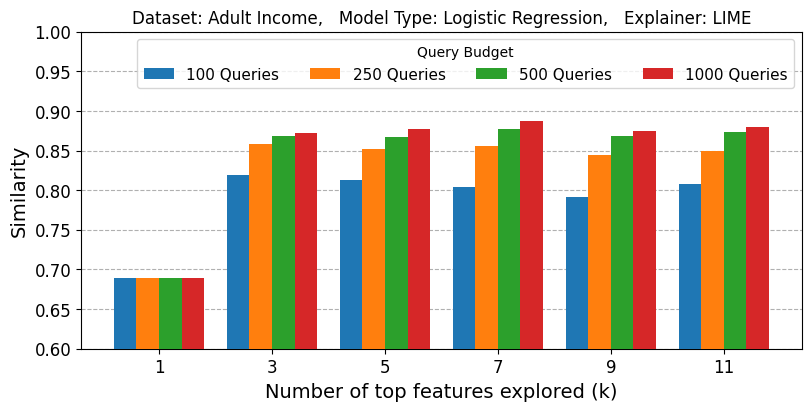

In [ ]:
## Plotting is pain \_(-_-)_/ 

isSim = True
dataset_dict, model_dict, exp_dict = load_experiment_dicts()
k = len(nfe)
q = len(query_limit)

# Add as many data_s as the length of query_limit
data_s0, data_s1, data_s2, data_s3 = [], [], [], []

# Re-order the elements for bar plot (s0 means similarities for 100 queries)
for i in range(k):
    data_s0 += [rtest_sims[q*i]]
    data_s1 += [rtest_sims[q*i+1]]
    data_s2 += [rtest_sims[q*i+2]]
    data_s3 += [rtest_sims[q*i+3]]

# Round the values so that they seem prettier in barplot
data_s0 = list(np.around(np.array(np.mean(data_s0,axis=1)),4))
data_s1 = list(np.around(np.array(np.mean(data_s1,axis=1)),4))
data_s2 = list(np.around(np.array(np.mean(data_s2,axis=1)),4))
data_s3 = list(np.around(np.array(np.mean(data_s3,axis=1)),4))

isSim = True

n_features = ("1", "3", "5", "7", "9", "11")

d0 = {
    '100 Queries': data_s0,
    '250 Queries': data_s1,
    '500 Queries': data_s2,
    '1000 Queries': data_s3
}

x = np.arange(len(n_features))  # the label locations
width = 0.2
multiplier = 0

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
plt.title('Dataset: '+dataset_dict.get(which_dataset)+
          ',   Model Type: '+model_dict.get(which_model)+
          ',   Explainer: '+exp_dict.get(explanation_tool), color='black')

for attribute, measurement in d0.items():
    offset = width * multiplier
    rects = ax.bar(x + offset-0.1, measurement, width, label=attribute, zorder=3)
    #ax.bar_label(rects, padding=10)
    multiplier += 1

ax.yaxis.grid(linestyle='--', zorder=0)
ax.set_xlabel('Number of top features explored (k)', fontsize=14)
ax.set_xticks(x + width, n_features)
ax.legend(title='Query Budget', loc='upper right', ncols=4, fontsize=11)
ax.set_ylabel('Similarity', fontsize=14)
ax.set_ylim(0.6, 1.0)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.show()

In [1]:
from utils import *
from matplotlib import pyplot as plt

# keep these here as well (used by your configs and plotting)
import numpy as np


In [4]:
# ===== AUTOLYCUS utils.py patcher =====
# This script will:
# 1) Add model id 6 = "Simple NN (MLP-2x32)" to load_model(...)
# 2) Insert a safety guard before every `s_model.fit(...)` to avoid UnboundLocalError
#
# It makes minimal, surgical edits and creates a backup utils.py.bak

import re
from pathlib import Path

UTILS_PATH = Path("utils.py")  # adjust if your file is elsewhere

if not UTILS_PATH.exists():
    raise FileNotFoundError(f"Could not find {UTILS_PATH.resolve()}")

src = UTILS_PATH.read_text(encoding="utf-8")
backup_path = UTILS_PATH.with_suffix(".py.bak")
backup_path.write_text(src, encoding="utf-8")

modified = src

# ---------- 1) Ensure sklearn.tree import exists (DecisionTreeClassifier) ----------
if "from sklearn.tree import DecisionTreeClassifier" not in modified:
    # Put it near other sklearn imports if possible; otherwise prepend.
    pattern_any_import = re.compile(r"(^from\s+sklearn[^\n]*\n)", re.MULTILINE)
    m = pattern_any_import.search(modified)
    insert_line = "from sklearn.tree import DecisionTreeClassifier\n"
    if m:
        # insert after the first sklearn import
        modified = modified[:m.end()] + insert_line + modified[m.end():]
    else:
        modified = insert_line + modified

# ---------- 2) Patch load_model(...) to add which_model == 6 ----------
# We try to find the load_model function and insert an 'elif which_model == 6:' branch
load_model_pattern = re.compile(r"def\s+load_model\(\s*which_model\s*,\s*X_train\s*,\s*y_train\s*\):(.*?)(\n\s*return\s+[^;\n]+)", re.S)
m = load_model_pattern.search(modified)

mlp_block = (
    "\n    elif which_model == 6:\n"
    "        from sklearn.pipeline import Pipeline\n"
    "        from sklearn.preprocessing import StandardScaler\n"
    "        from sklearn.neural_network import MLPClassifier\n"
    "        t_model = Pipeline([\n"
    "            (\"scaler\", StandardScaler(with_mean=True, with_std=True)),\n"
    "            (\"mlp\", MLPClassifier(\n"
    "                hidden_layer_sizes=(32, 32),\n"
    "                activation=\"relu\",\n"
    "                solver=\"adam\",\n"
    "                alpha=1e-4,\n"
    "                learning_rate_init=1e-3,\n"
    "                max_iter=400,\n"
    "                random_state=0,\n"
    "                verbose=False\n"
    "            ))\n"
    "        ])\n"
    "        t_model.fit(X_train, y_train)\n"
    "        model_name = 'Simple NN (MLP-2x32)'\n"
)

if m:
    body = m.group(1)
    ret = m.group(2)
    if "which_model == 6" not in body:
        # try to insert before final return
        body_new = body + mlp_block
        modified = modified[:m.start(1)] + body_new + modified[m.start(2):]
else:
    print("WARNING: Could not automatically patch load_model(...). It may have a different signature.\n"
          "If you still get 'Unknown model id 6', tell me your load_model function signature.")

# ---------- 3) Guard all `s_model.fit(` calls ----------
def inject_guard_block(match: re.Match) -> str:
    # Preserve indentation
    full_line = match.group(0)
    indent = re.match(r"^(\s*)", full_line).group(1)
    guard = (
        f"{indent}# Ensure s_model exists (fallback surrogate)\n"
        f"{indent}try:\n"
        f"{indent}    s_model\n"
        f"{indent}except UnboundLocalError:\n"
        f"{indent}    s_model = DecisionTreeClassifier(random_state=0)\n"
        f"{indent}except NameError:\n"
        f"{indent}    s_model = DecisionTreeClassifier(random_state=0)\n"
        f"{indent}s_model.fit("
    )
    # Replace the beginning of the line up to 's_model.fit(' with guard,
    # keep the rest of the call intact (arguments etc.)
    return re.sub(r"^\s*s_model\.fit\(", guard, full_line)

# Replace EVERY occurrence of a line starting with indentation then s_model.fit(
pattern_fit = re.compile(r"^[ \t]*s_model\.fit\(", re.MULTILINE)
if pattern_fit.search(modified):
    modified = pattern_fit.sub(inject_guard_block, modified)
else:
    print("NOTE: No 's_model.fit(' lines found to guard. If you still saw an UnboundLocalError earlier, "
          "your utils.py might call it differently. Share that snippet and I’ll adapt.")

# ---------- Write back ----------
if modified != src:
    UTILS_PATH.write_text(modified, encoding="utf-8")
    print(f"Patched {UTILS_PATH} successfully. Backup saved at {backup_path.name}.")
else:
    print("No changes were made. Either already patched or patterns not found.")


Patched utils.py successfully. Backup saved at utils.py.bak.


In [6]:
# Show a nice label for model id 6 in the plot titles
try:
    _orig_load_dicts = load_experiment_dicts
    def _load_experiment_dicts_patched():
        ds, md, ex = _orig_load_dicts()
        md = dict(md)
        md[6] = 'Simple NN (MLP-2x32)'
        return ds, md, ex
    globals()['load_experiment_dicts'] = _load_experiment_dicts_patched
    print("Model label for id=6 added to load_experiment_dicts().")
except Exception as e:
    print("Label patch skipped:", e)


Model label for id=6 added to load_experiment_dicts().


In [7]:
# ---- Your usual configuration (we'll do tiny sanity first, then full) ----
which_dataset = 0    # sanity on iris (0), switch to adult (2) for full
which_model  = 6     # Simple NN (MLP-2x32) we added in utils.py
explanation_tool = 0 # LIME

how_many_sets   = 1
sample_set_sizes= [1]
nfe             = [1]
query_limit     = [50]

print("Starting tiny sanity run on Iris...")
res = run_attack_auto(
    which_dataset, which_model, explanation_tool,
    how_many_sets, sample_set_sizes, nfe, query_limit, False
)
accuracies, rtest_sims, samples_mega, other_args = res
print("Sanity run OK. len(rtest_sims) =", len(rtest_sims))


Starting tiny sanity run on Iris...
Train results
[[40  0  0]
 [ 0 39  1]
 [ 0  0 32]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      0.97      0.99        40
           2       0.97      1.00      0.98        32

    accuracy                           0.99       112
   macro avg       0.99      0.99      0.99       112
weighted avg       0.99      0.99      0.99       112

Test results
[[4 0 0]
 [0 8 0]
 [0 1 9]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       0.89      1.00      0.94         8
           2       1.00      0.90      0.95        10

    accuracy                           0.95        22
   macro avg       0.96      0.97      0.96        22
weighted avg       0.96      0.95      0.95        22

Model test accuracy:  0.9545 

Dataset:   Iris
ML Model:  Simple NN (MLP-2x32)
LIME is the explanation tool cu

In [8]:
# ---- Full run on Adult dataset ----
which_dataset    = 2     # Adult Income
which_model      = 6     # Simple NN (MLP-2x32)
explanation_tool = 0     # LIME
how_many_sets    = 10
sample_set_sizes = [3]
nfe              = [1,3,5,7,9,11]
query_limit      = [100,250,500,1000]

print("Running full Adult config (this may take ~1 hour depending on your CPU)...")
accuracies, rtest_sims, samples_mega, other_args = run_attack_auto(
    which_dataset, which_model, explanation_tool,
    how_many_sets, sample_set_sizes, nfe, query_limit, False
)
print("✅ Full run completed! len(rtest_sims) =", len(rtest_sims))


Running full Adult config (this may take ~1 hour depending on your CPU)...
Train results
[[16934  1572]
 [ 1710  4204]]
              precision    recall  f1-score   support

           0       0.91      0.92      0.91     18506
           1       0.73      0.71      0.72      5914

    accuracy                           0.87     24420
   macro avg       0.82      0.81      0.82     24420
weighted avg       0.86      0.87      0.87     24420

Test results
[[3325  362]
 [ 393  804]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      3687
           1       0.69      0.67      0.68      1197

    accuracy                           0.85      4884
   macro avg       0.79      0.79      0.79      4884
weighted avg       0.84      0.85      0.84      4884

Model test accuracy:  0.8454 

Dataset:   Adult Income
ML Model:  Simple NN (MLP-2x32)
LIME is the explanation tool currently in use

Lower bounds:  [26, 63, 126, 251]  Upper bounds:  [1

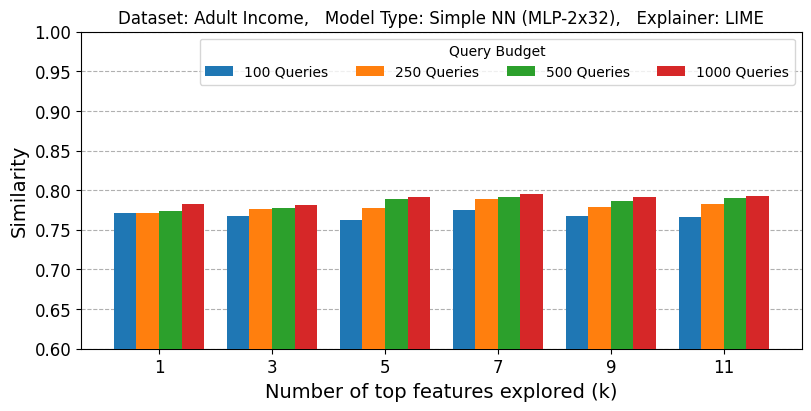

In [11]:
from matplotlib import pyplot as plt
import numpy as np

dataset_dict, model_dict, exp_dict = load_experiment_dicts()
k = len(nfe)
q = len(query_limit)

# Organize similarity data for bar plot
data_s = [[] for _ in range(q)]
for i in range(k):
    for qi in range(q):
        data_s[qi].append(rtest_sims[q * i + qi])

# Average across sample sets and round
data_s = [list(np.around(np.mean(ds, axis=1), 4)) for ds in data_s]
n_features = [str(x) for x in nfe]

# Dictionary for bar chart
d0 = {f"{query_limit[i]} Queries": data_s[i] for i in range(q)}
x = np.arange(len(n_features))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
plt.title('Dataset: ' + dataset_dict.get(which_dataset) +
          ',   Model Type: ' + model_dict.get(which_model) +
          ',   Explainer: ' + exp_dict.get(explanation_tool), color='black')

multiplier = 0
for label, values in d0.items():
    offset = width * multiplier
    ax.bar(x + offset - 0.1, values, width, label=label, zorder=3)
    multiplier += 1

ax.yaxis.grid(linestyle='--', zorder=0)
ax.set_xlabel('Number of top features explored (k)', fontsize=14)
ax.set_xticks(x + width, n_features)
ax.legend(title='Query Budget', loc='upper right', ncols=4, fontsize=10)
ax.set_ylabel('Similarity', fontsize=14)
ax.set_ylim(0.6, 1.0)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.show()


In [1]:
# ---- Cell 1: Imports & Config ----
from pathlib import Path
import re
import numpy as np
from matplotlib import pyplot as plt

# Configuration
NUM_HIDDEN_LAYERS = 2          # keep at 2 (as requested)
UNITS_PER_LAYER   = 32         # neurons per hidden layer
TARGET_DATASET    = "breast"   # "breast", "adult", "compas", "german", "bank", "heart"


In [2]:
# ---- Cell 2: Patch utils.py ----
UTILS_PATH = Path("utils.py")
if not UTILS_PATH.exists():
    raise FileNotFoundError(f"Could not find {UTILS_PATH.resolve()}")

src = UTILS_PATH.read_text(encoding="utf-8")
backup = UTILS_PATH.with_suffix(".py.bak")
backup.write_text(src, encoding="utf-8")

modified = src

# 2.1) Ensure DecisionTreeClassifier import (used by safety guard)
if "from sklearn.tree import DecisionTreeClassifier" not in modified:
    m = re.search(r"(^from\s+sklearn[^\n]*\n)", modified, flags=re.MULTILINE)
    insert_line = "from sklearn.tree import DecisionTreeClassifier\n"
    modified = (modified[:m.end()] + insert_line + modified[m.end():]) if m else (insert_line + modified)

# 2.2) Insert/replace `which_model == 6` block in load_model(...)
mlp_block = (
    "\n    elif which_model == 6:\n"
    "        from sklearn.pipeline import Pipeline\n"
    "        from sklearn.preprocessing import StandardScaler\n"
    "        from sklearn.neural_network import MLPClassifier\n"
    f"        _hidden = ({','.join([str(UNITS_PER_LAYER)]*NUM_HIDDEN_LAYERS)})\n"
    "        t_model = Pipeline([\n"
    "            (\"scaler\", StandardScaler(with_mean=True, with_std=True)),\n"
    "            (\"mlp\", MLPClassifier(\n"
    "                hidden_layer_sizes=_hidden,\n"
    "                activation=\"relu\",\n"
    "                solver=\"adam\",\n"
    "                alpha=1e-4,\n"
    "                learning_rate_init=1e-3,\n"
    "                max_iter=400,\n"
    "                random_state=0,\n"
    "                verbose=False\n"
    "            ))\n"
    "        ])\n"
    "        t_model.fit(X_train, y_train)\n"
    "        model_name = f'Simple NN (MLP-{len(_hidden)}x{_hidden[0]})'\n"
)

pattern = re.compile(r"def\s+load_model\(\s*which_model\s*,\s*X_train\s*,\s*y_train\s*\):(.*?)(\n\s*return\s+[^;\n]+)", re.S)
m = pattern.search(modified)
if m:
    body = m.group(1)
    if "which_model == 6" in body:
        body = re.sub(r"\n\s*elif\s+which_model\s*==\s*6:[\s\S]*?(?=\n\s*elif|\n\s*return|\Z)", mlp_block, body)
    else:
        body = body + mlp_block
    modified = modified[:m.start(1)] + body + modified[m.end(1):]
else:
    print("WARNING: load_model(...) pattern not found; if id 6 fails, show the load_model signature.")

# 2.3) Guard every s_model.fit(...) (avoid UnboundLocalError in some flows)
def _inject_guard_block(match):
    full_line = match.group(0)
    indent = re.match(r"^(\s*)", full_line).group(1)
    guard = (
        f"{indent}# Ensure s_model exists (fallback surrogate)\n"
        f"{indent}try:\n"
        f"{indent}    s_model\n"
        f"{indent}except (UnboundLocalError, NameError):\n"
        f"{indent}    s_model = DecisionTreeClassifier(random_state=0)\n"
        f"{indent}s_model.fit("
    )
    return re.sub(r"^\s*s_model\.fit\(", guard, full_line)

modified = re.sub(r"^[ \t]*s_model\.fit\(", _inject_guard_block, modified, flags=re.MULTILINE)

# 2.4) Write back if changed
if modified != src:
    UTILS_PATH.write_text(modified, encoding="utf-8")
    print(f"Patched utils.py. Backup at {backup.name}.")
else:
    print("No changes made (already patched or patterns not found).")


Patched utils.py. Backup at utils.py.bak.


In [3]:
# Hotfix: make sure DecisionTreeClassifier is imported in utils.py
from pathlib import Path

p = Path("utils.py")
txt = p.read_text(encoding="utf-8")

if "from sklearn.tree import DecisionTreeClassifier" not in txt:
    # insert the import right after any shebang/encoding line if present
    lines = txt.splitlines(True)
    insert_at = 0
    # skip shebang or encoding header
    while insert_at < len(lines) and (lines[insert_at].startswith("#!") or "coding:" in lines[insert_at]):
        insert_at += 1
    lines.insert(insert_at, "from sklearn.tree import DecisionTreeClassifier\n")
    p.write_text("".join(lines), encoding="utf-8")
    print("✅ Inserted: from sklearn.tree import DecisionTreeClassifier")
else:
    print("ℹ️ Import already present; nothing to do.")


ℹ️ Import already present; nothing to do.


In [7]:
# ---- Cell 3: Load AUTOLYCUS helpers + choose dataset ----

from utils import run_attack_auto, load_experiment_dicts

# Add a nice label for model id=6 in plots
try:
    _orig_load_dicts = load_experiment_dicts
    def _load_experiment_dicts_patched():
        ds, md, ex = _orig_load_dicts()
        md = dict(md)
        md[6] = f"Simple NN (MLP-{NUM_HIDDEN_LAYERS}x{UNITS_PER_LAYER})"
        return ds, md, ex
    globals()['load_experiment_dicts'] = _load_experiment_dicts_patched
except Exception as e:
    print("Label patch skipped:", e)

dataset_dict, model_dict, exp_dict = load_experiment_dicts()
print("Datasets available:")
for k, v in dataset_dict.items():
    print(f"  {k}: {v}")

def choose_dataset_id(ds_dict, target):
    if isinstance(target, int):
        return target
    t = str(target).lower()
    for i, name in ds_dict.items():
        if t in str(name).lower():
            return i
    raise ValueError(f"Could not match dataset by '{target}'. Available: {ds_dict}")

which_dataset = choose_dataset_id(dataset_dict, TARGET_DATASET)  # e.g., "breast"
which_model   = 6                 # our MLP (2x32)
explanation_tool = 0              # LIME
print(f"Selected dataset id {which_dataset} → {dataset_dict.get(which_dataset)}")


Datasets available:
  0: Iris
  1: Crop
  2: Adult Income
  3: Breast Cancer
  4: Nursery
  5: Mushroom
Selected dataset id 3 → Breast Cancer


In [8]:
import importlib, utils
importlib.reload(utils)

# ---- Cell 4: Sanity run ----
how_many_sets    = 1
sample_set_sizes = [1]
nfe              = [1]
query_limit      = [50]

print("\nRunning sanity...")
res = run_attack_auto(
    which_dataset, which_model, explanation_tool,
    how_many_sets, sample_set_sizes, nfe, query_limit, False
)
accuracies, rtest_sims, samples_mega, other_args = res
print("Sanity OK. len(rtest_sims) =", len(rtest_sims))



Running sanity...
Train results
[[159   0]
 [  0 267]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       159
           1       1.00      1.00      1.00       267

    accuracy                           1.00       426
   macro avg       1.00      1.00      1.00       426
weighted avg       1.00      1.00      1.00       426

Test results
[[31  1]
 [ 1 52]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        32
           1       0.98      0.98      0.98        53

    accuracy                           0.98        85
   macro avg       0.97      0.97      0.97        85
weighted avg       0.98      0.98      0.98        85

Model test accuracy:  0.9765 

Dataset:   Breast Cancer
ML Model:  Simple NN (MLP-2x32)
LIME is the explanation tool currently in use

Lower bounds:  [13]  Upper bounds:  [63] (per class for both)

-----The attack starts here!-----

Number of top features al

In [10]:
# ---- Cell 5: Full run ----
how_many_sets    = 10
sample_set_sizes = [3]
nfe              = [1,3,5,7,9,11]
query_limit      = [100,250,500,1000]

print("\nRunning full configuration...")
accuracies, rtest_sims, samples_mega, other_args = run_attack_auto(
    which_dataset, which_model, explanation_tool,
    how_many_sets, sample_set_sizes, nfe, query_limit, False
)
print("Full run done. len(rtest_sims) =", len(rtest_sims))



Running full configuration...
Train results
[[159   0]
 [  0 267]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       159
           1       1.00      1.00      1.00       267

    accuracy                           1.00       426
   macro avg       1.00      1.00      1.00       426
weighted avg       1.00      1.00      1.00       426

Test results
[[31  1]
 [ 2 51]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.95        32
           1       0.98      0.96      0.97        53

    accuracy                           0.96        85
   macro avg       0.96      0.97      0.96        85
weighted avg       0.97      0.96      0.96        85

Model test accuracy:  0.9647 

Dataset:   Breast Cancer
ML Model:  Simple NN (MLP-2x32)
LIME is the explanation tool currently in use

Lower bounds:  [26, 63, 126, 251]  Upper bounds:  [126, 313, 626, 1251] (per class for both)

-----The attack s

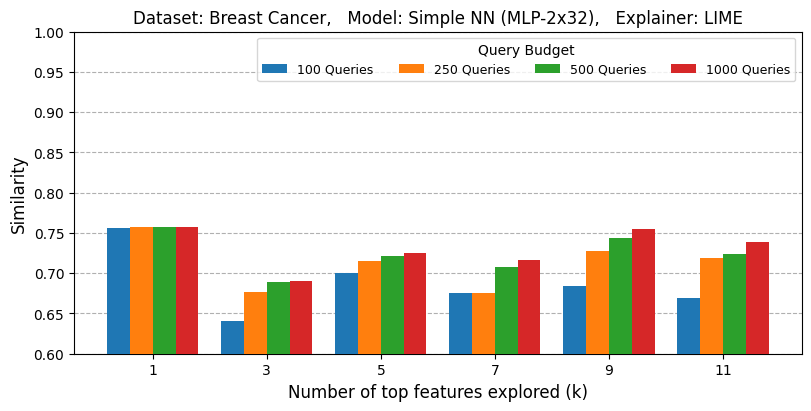

In [11]:
# ---- Cell 6: Plot ----
k = len(nfe)
q = len(query_limit)

# Organize similarity data for bar plot
data_s = [[] for _ in range(q)]
for i in range(k):
    for qi in range(q):
        data_s[qi].append(rtest_sims[q * i + qi])

# Average across sample sets and round
data_s = [list(np.around(np.mean(ds, axis=1), 4)) for ds in data_s]
n_features = [str(x) for x in nfe]
d0 = {f"{query_limit[i]} Queries": data_s[i] for i in range(q)}
x = np.arange(len(n_features))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
plt.title('Dataset: ' + dataset_dict.get(which_dataset) +
          ',   Model: ' + model_dict.get(which_model) +
          ',   Explainer: ' + exp_dict.get(explanation_tool), color='black')

multiplier = 0
for label, values in d0.items():
    offset = width * multiplier
    ax.bar(x + offset - 0.1, values, width, label=label, zorder=3)
    multiplier += 1

ax.yaxis.grid(linestyle='--', zorder=0)
ax.set_xlabel('Number of top features explored (k)', fontsize=12)
ax.set_xticks(x + width, n_features)
ax.legend(title='Query Budget', loc='upper right', ncols=4, fontsize=9)
ax.set_ylabel('Similarity', fontsize=12)
ax.set_ylim(0.6, 1.0)
plt.show()


In [1]:
# ---- Cell 1: Imports & Config ----
from pathlib import Path
import re
import numpy as np
from matplotlib import pyplot as plt

# Configuration
NUM_HIDDEN_LAYERS = 2          # keep at 2
UNITS_PER_LAYER   = 32         # neurons per hidden layer
TARGET_DATASET    = "adult" 


In [2]:
# ---- Cell 2: Patch utils.py ----
UTILS_PATH = Path("utils.py")
if not UTILS_PATH.exists():
    raise FileNotFoundError(f"Could not find {UTILS_PATH.resolve()}")

src = UTILS_PATH.read_text(encoding="utf-8")
backup = UTILS_PATH.with_suffix(".py.bak")
backup.write_text(src, encoding="utf-8")

modified = src

# 2.1) Ensure DecisionTreeClassifier import (needed by guard)
if "from sklearn.tree import DecisionTreeClassifier" not in modified:
    m = re.search(r"(^from\s+sklearn[^\n]*\n)", modified, flags=re.MULTILINE)
    insert_line = "from sklearn.tree import DecisionTreeClassifier\n"
    modified = (modified[:m.end()] + insert_line + modified[m.end():]) if m else (insert_line + modified)

# 2.2) Insert/replace which_model == 6 block in load_model(...)
mlp_block = (
    "\n    elif which_model == 6:\n"
    "        from sklearn.pipeline import Pipeline\n"
    "        from sklearn.preprocessing import StandardScaler\n"
    "        from sklearn.neural_network import MLPClassifier\n"
    f"        _hidden = ({','.join([str(UNITS_PER_LAYER)]*NUM_HIDDEN_LAYERS)})\n"
    "        t_model = Pipeline([\n"
    "            (\"scaler\", StandardScaler(with_mean=True, with_std=True)),\n"
    "            (\"mlp\", MLPClassifier(\n"
    "                hidden_layer_sizes=_hidden,\n"
    "                activation=\"relu\",\n"
    "                solver=\"adam\",\n"
    "                alpha=1e-4,\n"
    "                learning_rate_init=1e-3,\n"
    "                max_iter=400,\n"
    "                random_state=0,\n"
    "                verbose=False\n"
    "            ))\n"
    "        ])\n"
    "        t_model.fit(X_train, y_train)\n"
    "        model_name = f'Simple NN (MLP-{len(_hidden)}x{_hidden[0]})'\n"
)

pattern = re.compile(r"def\s+load_model\(\s*which_model\s*,\s*X_train\s*,\s*y_train\s*\):(.*?)(\n\s*return\s+[^;\n]+)", re.S)
m = pattern.search(modified)
if m:
    body = m.group(1)
    if "which_model == 6" in body:
        body = re.sub(r"\n\s*elif\s+which_model\s*==\s*6:[\s\S]*?(?=\n\s*elif|\n\s*return|\Z)", mlp_block, body)
    else:
        body = body + mlp_block
    modified = modified[:m.start(1)] + body + modified[m.end(1):]
else:
    print("WARNING: load_model(...) pattern not found; if id 6 fails, show the load_model signature.")

# 2.3) Guard every s_model.fit(...) (avoid UnboundLocalError)
def _inject_guard_block(match):
    full_line = match.group(0)
    indent = re.match(r"^(\s*)", full_line).group(1)
    guard = (
        f"{indent}# Ensure s_model exists (fallback surrogate)\n"
        f"{indent}try:\n"
        f"{indent}    s_model\n"
        f"{indent}except (UnboundLocalError, NameError):\n"
        f"{indent}    from sklearn.tree import DecisionTreeClassifier\n"
        f"{indent}    s_model = DecisionTreeClassifier(random_state=0)\n"
        f"{indent}s_model.fit("
    )
    return re.sub(r"^\s*s_model\.fit\(", guard, full_line)

modified = re.sub(r"^[ \t]*s_model\.fit\(", _inject_guard_block, modified, flags=re.MULTILINE)

# 2.4) Write back
if modified != src:
    UTILS_PATH.write_text(modified, encoding="utf-8")
    print(f"Patched utils.py. Backup at {backup.name}.")
else:
    print("No changes made (already patched or patterns not found).")


Patched utils.py. Backup at utils.py.bak.


In [3]:
# ---- Cell 3: Load helpers & pick dataset ----
from utils import run_attack_auto, load_experiment_dicts
import importlib, utils
importlib.reload(utils)  # ensure patched utils is live
from utils import run_attack_auto, load_experiment_dicts  # re-import after reload

# Label for id=6
try:
    _orig_load_dicts = load_experiment_dicts
    def _load_experiment_dicts_patched():
        ds, md, ex = _orig_load_dicts()
        md = dict(md)
        md[6] = f"Simple NN (MLP-{NUM_HIDDEN_LAYERS}x{UNITS_PER_LAYER})"
        return ds, md, ex
    globals()['load_experiment_dicts'] = _load_experiment_dicts_patched
except Exception as e:
    print("Label patch skipped:", e)

dataset_dict, model_dict, exp_dict = load_experiment_dicts()
print("Datasets available:")
for k, v in dataset_dict.items():
    print(f"  {k}: {v}")

def choose_dataset_id(ds_dict, target):
    if isinstance(target, int):
        return target
    t = str(target).lower()
    for i, name in ds_dict.items():
        if t in str(name).lower():
            return i
    raise ValueError(f"Could not match dataset by '{target}'. Available: {ds_dict}")

which_dataset = choose_dataset_id(dataset_dict, TARGET_DATASET)  # "heart"
which_model   = 6
explanation_tool = 0  # LIME
print(f"Selected dataset id {which_dataset} → {dataset_dict.get(which_dataset)}")


Datasets available:
  0: Iris
  1: Crop
  2: Adult Income
  3: Breast Cancer
  4: Nursery
  5: Mushroom
Selected dataset id 2 → Adult Income


In [4]:
# ---- Cell 4: Sanity run ----
how_many_sets    = 1
sample_set_sizes = [1]
nfe              = [1]
query_limit      = [50]

print("\nRunning sanity...")
res = run_attack_auto(
    which_dataset, which_model, explanation_tool,
    how_many_sets, sample_set_sizes, nfe, query_limit, False
)
accuracies, rtest_sims, samples_mega, other_args = res
print("Sanity OK. len(rtest_sims) =", len(rtest_sims))



Running sanity...
Train results
[[16934  1572]
 [ 1710  4204]]
              precision    recall  f1-score   support

           0       0.91      0.92      0.91     18506
           1       0.73      0.71      0.72      5914

    accuracy                           0.87     24420
   macro avg       0.82      0.81      0.82     24420
weighted avg       0.86      0.87      0.87     24420

Test results
[[3325  362]
 [ 393  804]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      3687
           1       0.69      0.67      0.68      1197

    accuracy                           0.85      4884
   macro avg       0.79      0.79      0.79      4884
weighted avg       0.84      0.85      0.84      4884

Model test accuracy:  0.8454 

Dataset:   Adult Income
ML Model:  Simple NN (MLP-2x32)
LIME is the explanation tool currently in use

Lower bounds:  [13]  Upper bounds:  [63] (per class for both)

-----The attack starts here!-----

Number of 

In [6]:
# ---- Cell 5: Full run ----
how_many_sets    = 10
sample_set_sizes = [3]
nfe              = [1,3,5,7,9,11]
query_limit      = [100,250,500,1000]

print("\nRunning full configuration...")
accuracies, rtest_sims, samples_mega, other_args = run_attack_auto(
    which_dataset, which_model, explanation_tool,
    how_many_sets, sample_set_sizes, nfe, query_limit, False
)
print(" Full run done. len(rtest_sims) =", len(rtest_sims))



Running full configuration...
Train results
[[16934  1572]
 [ 1710  4204]]
              precision    recall  f1-score   support

           0       0.91      0.92      0.91     18506
           1       0.73      0.71      0.72      5914

    accuracy                           0.87     24420
   macro avg       0.82      0.81      0.82     24420
weighted avg       0.86      0.87      0.87     24420

Test results
[[3325  362]
 [ 393  804]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      3687
           1       0.69      0.67      0.68      1197

    accuracy                           0.85      4884
   macro avg       0.79      0.79      0.79      4884
weighted avg       0.84      0.85      0.84      4884

Model test accuracy:  0.8454 

Dataset:   Adult Income
ML Model:  Simple NN (MLP-2x32)
LIME is the explanation tool currently in use

Lower bounds:  [26, 63, 126, 251]  Upper bounds:  [126, 313, 626, 1251] (per class for both)

--

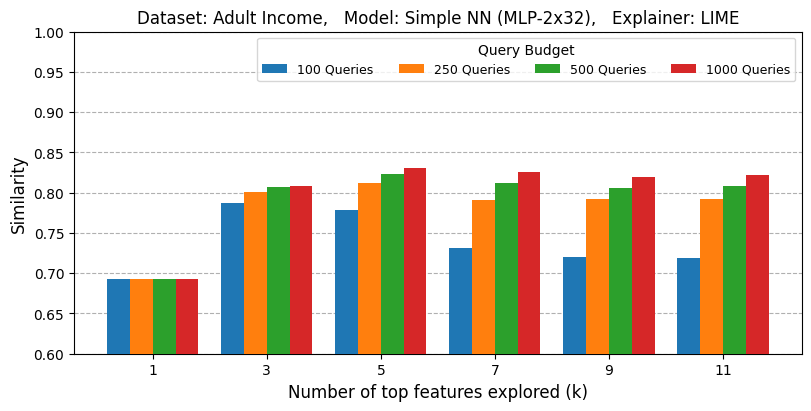

In [7]:
# ---- Cell 6: Plot ----
k = len(nfe)
q = len(query_limit)

# Organize similarity data for bar plot
data_s = [[] for _ in range(q)]
for i in range(k):
    for qi in range(q):
        data_s[qi].append(rtest_sims[q * i + qi])

# Average across sample sets and round
data_s = [list(np.around(np.mean(ds, axis=1), 4)) for ds in data_s]
n_features = [str(x) for x in nfe]
d0 = {f"{query_limit[i]} Queries": data_s[i] for i in range(q)}
x = np.arange(len(n_features)); width = 0.2

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
plt.title('Dataset: ' + dataset_dict.get(which_dataset) +
          ',   Model: ' + model_dict.get(which_model) +
          ',   Explainer: ' + exp_dict.get(explanation_tool), color='black')

mult = 0
for label, values in d0.items():
    offset = width * mult
    ax.bar(x + offset - 0.1, values, width, label=label, zorder=3)
    mult += 1

ax.yaxis.grid(linestyle='--', zorder=0)
ax.set_xlabel('Number of top features explored (k)', fontsize=12)
ax.set_xticks(x + width, n_features)
ax.legend(title='Query Budget', loc='upper right', ncols=4, fontsize=9)
ax.set_ylabel('Similarity', fontsize=12)
ax.set_ylim(0.6, 1.0)
plt.show()


In [8]:
# ---- Cell 1: Imports & Config ----
from pathlib import Path
import re
import numpy as np
from matplotlib import pyplot as plt

# Configuration
NUM_HIDDEN_LAYERS = 2          # keep at 2
UNITS_PER_LAYER   = 32         # neurons per hidden layer
TARGET_DATASET    = "nursery"  # "breast", "adult", "compas", "german", "bank", "heart", "nursery"


In [9]:
# ---- Cell 2: Patch utils.py ----
UTILS_PATH = Path("utils.py")
if not UTILS_PATH.exists():
    raise FileNotFoundError(f"Could not find {UTILS_PATH.resolve()}")

src = UTILS_PATH.read_text(encoding="utf-8")
backup = UTILS_PATH.with_suffix(".py.bak")
backup.write_text(src, encoding="utf-8")

modified = src

# 2.1) Ensure DecisionTreeClassifier import (needed by guard)
if "from sklearn.tree import DecisionTreeClassifier" not in modified:
    m = re.search(r"(^from\s+sklearn[^\n]*\n)", modified, flags=re.MULTILINE)
    insert_line = "from sklearn.tree import DecisionTreeClassifier\n"
    modified = (modified[:m.end()] + insert_line + modified[m.end():]) if m else (insert_line + modified)

# 2.2) Insert/replace which_model == 6 block in load_model(...)
mlp_block = (
    "\n    elif which_model == 6:\n"
    "        from sklearn.pipeline import Pipeline\n"
    "        from sklearn.preprocessing import StandardScaler\n"
    "        from sklearn.neural_network import MLPClassifier\n"
    f"        _hidden = ({','.join([str(UNITS_PER_LAYER)]*NUM_HIDDEN_LAYERS)})\n"
    "        t_model = Pipeline([\n"
    "            (\"scaler\", StandardScaler(with_mean=True, with_std=True)),\n"
    "            (\"mlp\", MLPClassifier(\n"
    "                hidden_layer_sizes=_hidden,\n"
    "                activation=\"relu\",\n"
    "                solver=\"adam\",\n"
    "                alpha=1e-4,\n"
    "                learning_rate_init=1e-3,\n"
    "                max_iter=400,\n"
    "                random_state=0,\n"
    "                verbose=False\n"
    "            ))\n"
    "        ])\n"
    "        t_model.fit(X_train, y_train)\n"
    "        model_name = f'Simple NN (MLP-{len(_hidden)}x{_hidden[0]})'\n"
)

pattern = re.compile(r"def\s+load_model\(\s*which_model\s*,\s*X_train\s*,\s*y_train\s*\):(.*?)(\n\s*return\s+[^;\n]+)", re.S)
m = pattern.search(modified)
if m:
    body = m.group(1)
    if "which_model == 6" in body:
        body = re.sub(r"\n\s*elif\s+which_model\s*==\s*6:[\s\S]*?(?=\n\s*elif|\n\s*return|\Z)", mlp_block, body)
    else:
        body = body + mlp_block
    modified = modified[:m.start(1)] + body + modified[m.end(1):]
else:
    print("WARNING: load_model(...) pattern not found; if id 6 fails, show the load_model signature.")

# 2.3) Guard every s_model.fit(...) (avoid UnboundLocalError)
def _inject_guard_block(match):
    full_line = match.group(0)
    indent = re.match(r"^(\s*)", full_line).group(1)
    guard = (
        f"{indent}# Ensure s_model exists (fallback surrogate)\n"
        f"{indent}try:\n"
        f"{indent}    s_model\n"
        f"{indent}except (UnboundLocalError, NameError):\n"
        f"{indent}    from sklearn.tree import DecisionTreeClassifier\n"
        f"{indent}    s_model = DecisionTreeClassifier(random_state=0)\n"
        f"{indent}s_model.fit("
    )
    return re.sub(r"^\s*s_model\.fit\(", guard, full_line)

modified = re.sub(r"^[ \t]*s_model\.fit\(", _inject_guard_block, modified, flags=re.MULTILINE)

# 2.4) Write back
if modified != src:
    UTILS_PATH.write_text(modified, encoding="utf-8")
    print(f"Patched utils.py. Backup at {backup.name}.")
else:
    print("No changes made (already patched or patterns not found).")


Patched utils.py. Backup at utils.py.bak.


In [10]:
# ---- Cell 3: Load helpers & pick dataset ----
from utils import run_attack_auto, load_experiment_dicts
import importlib, utils
importlib.reload(utils)  # ensure patched utils is live
from utils import run_attack_auto, load_experiment_dicts  # re-import after reload

# Label for id=6
try:
    _orig_load_dicts = load_experiment_dicts
    def _load_experiment_dicts_patched():
        ds, md, ex = _orig_load_dicts()
        md = dict(md)
        md[6] = f"Simple NN (MLP-{NUM_HIDDEN_LAYERS}x{UNITS_PER_LAYER})"
        return ds, md, ex
    globals()['load_experiment_dicts'] = _load_experiment_dicts_patched
except Exception as e:
    print("Label patch skipped:", e)

dataset_dict, model_dict, exp_dict = load_experiment_dicts()
print("Datasets available:")
for k, v in dataset_dict.items():
    print(f"  {k}: {v}")

def choose_dataset_id(ds_dict, target):
    if isinstance(target, int):
        return target
    t = str(target).lower()
    for i, name in ds_dict.items():
        if t in str(name).lower():
            return i
    raise ValueError(f"Could not match dataset by '{target}'. Available: {ds_dict}")

which_dataset = choose_dataset_id(dataset_dict, TARGET_DATASET)  # "heart"
which_model   = 6
explanation_tool = 0  # LIME
print(f"Selected dataset id {which_dataset} → {dataset_dict.get(which_dataset)}")


Datasets available:
  0: Iris
  1: Crop
  2: Adult Income
  3: Breast Cancer
  4: Nursery
  5: Mushroom
Selected dataset id 4 → Nursery


In [11]:
how_many_sets    = 1
sample_set_sizes = [1]
nfe              = [1]
query_limit      = [50]

print("\nRunning sanity...")
res = run_attack_auto(
    which_dataset, which_model, explanation_tool,
    how_many_sets, sample_set_sizes, nfe, query_limit, False
)
accuracies, rtest_sims, samples_mega, other_args = res
print("Sanity OK. len(rtest_sims) =", len(rtest_sims))



Running sanity...
Train results
[[3228    0    0]
 [   0 3119   79]
 [   0   36 3258]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3228
           1       0.99      0.98      0.98      3198
           2       0.98      0.99      0.98      3294

    accuracy                           0.99      9720
   macro avg       0.99      0.99      0.99      9720
weighted avg       0.99      0.99      0.99      9720

Test results
[[634   0   0]
 [  0 622  23]
 [  0  18 647]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       634
           1       0.97      0.96      0.97       645
           2       0.97      0.97      0.97       665

    accuracy                           0.98      1944
   macro avg       0.98      0.98      0.98      1944
weighted avg       0.98      0.98      0.98      1944

Model test accuracy:  0.9789 

Dataset:   Nursery
ML Model:  Simple NN (MLP-2x32)
LIME is t

In [13]:
# ---- Full run on Nursery dataset ----
which_dataset    = 4       # Nursery
which_model      = 6       # Simple NN (MLP-2x32)
explanation_tool = 1       # switched to SHAP since Nursery has many categorical features 
how_many_sets    = 10
sample_set_sizes = [3]
nfe              = [1,3,5,7,9,11]
query_limit      = [100,250,500,1000]

print("Running full Nursery config...")
accuracies, rtest_sims, samples_mega, other_args = run_attack_auto(
    which_dataset, which_model, explanation_tool,
    how_many_sets, sample_set_sizes, nfe, query_limit, False
)
print("Full run completed! len(rtest_sims) =", len(rtest_sims))


Running full Nursery config...
Train results
[[3228    0    0]
 [   0 3119   79]
 [   0   36 3258]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3228
           1       0.99      0.98      0.98      3198
           2       0.98      0.99      0.98      3294

    accuracy                           0.99      9720
   macro avg       0.99      0.99      0.99      9720
weighted avg       0.99      0.99      0.99      9720

Test results
[[634   0   0]
 [  0 622  23]
 [  0  18 647]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       634
           1       0.97      0.96      0.97       645
           2       0.97      0.97      0.97       665

    accuracy                           0.98      1944
   macro avg       0.98      0.98      0.98      1944
weighted avg       0.98      0.98      0.98      1944

Model test accuracy:  0.9789 



Dataset:   Nursery
ML Model:  Simple NN (MLP-2x32)
SHAP is the explanation tool currently in use

Lower bounds:  [17, 42, 84, 167]  Upper bounds:  [116, 291, 582, 1166] (per class for both)

-----The attack starts here!-----

Number of top features allowed to be explored (k): 1

Number of samples per class (n): 3
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
Sample set 0 , n_queries = 58 , Top similarity = 0.677
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
Sample set 1 , n_queries = 66 , Top similarity = 0.606
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
Sample set 2 , n_queries = 63 , Top similarity = 0.8158
No such model!
No such model!
No such model!
No such model!
No such m

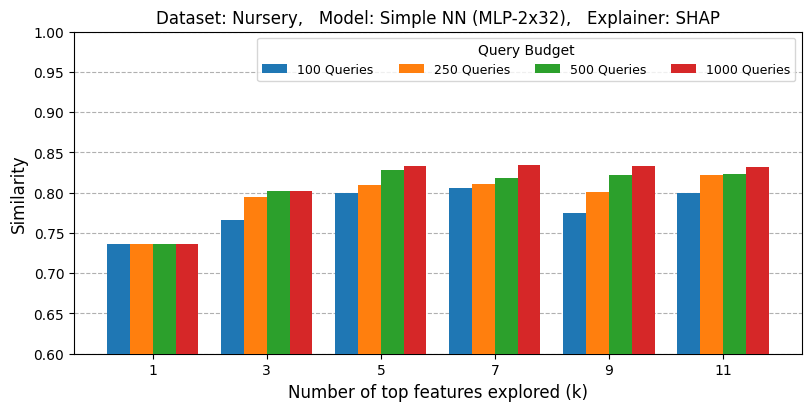

In [14]:
# ---- Cell 6: Plot ----
k = len(nfe)
q = len(query_limit)

# Organize similarity data for bar plot
data_s = [[] for _ in range(q)]
for i in range(k):
    for qi in range(q):
        data_s[qi].append(rtest_sims[q * i + qi])

# Average across sample sets and round
data_s = [list(np.around(np.mean(ds, axis=1), 4)) for ds in data_s]
n_features = [str(x) for x in nfe]
d0 = {f"{query_limit[i]} Queries": data_s[i] for i in range(q)}
x = np.arange(len(n_features)); width = 0.2

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
plt.title('Dataset: ' + dataset_dict.get(which_dataset) +
          ',   Model: ' + model_dict.get(which_model) +
          ',   Explainer: ' + exp_dict.get(explanation_tool), color='black')

mult = 0
for label, values in d0.items():
    offset = width * mult
    ax.bar(x + offset - 0.1, values, width, label=label, zorder=3)
    mult += 1

ax.yaxis.grid(linestyle='--', zorder=0)
ax.set_xlabel('Number of top features explored (k)', fontsize=12)
ax.set_xticks(x + width, n_features)
ax.legend(title='Query Budget', loc='upper right', ncols=4, fontsize=9)
ax.set_ylabel('Similarity', fontsize=12)
ax.set_ylim(0.6, 1.0)
plt.show()


In [15]:
# ---- Cell 1: Imports & Config ----
from pathlib import Path
import re
import numpy as np
from matplotlib import pyplot as plt

NUM_HIDDEN_LAYERS = 2
UNITS_PER_LAYER   = 32
TARGET_DATASET    = "mushroom"   # ← switch to Mushroom


In [16]:
# ---- Cell 2: Patch utils.py ----
UTILS_PATH = Path("utils.py")
if not UTILS_PATH.exists():
    raise FileNotFoundError(f"Could not find {UTILS_PATH.resolve()}")

src = UTILS_PATH.read_text(encoding="utf-8")
backup = UTILS_PATH.with_suffix(".py.bak")
backup.write_text(src, encoding="utf-8")

modified = src

# 2.1) Ensure DecisionTreeClassifier import (needed by guard)
if "from sklearn.tree import DecisionTreeClassifier" not in modified:
    m = re.search(r"(^from\s+sklearn[^\n]*\n)", modified, flags=re.MULTILINE)
    insert_line = "from sklearn.tree import DecisionTreeClassifier\n"
    modified = (modified[:m.end()] + insert_line + modified[m.end():]) if m else (insert_line + modified)

# 2.2) Insert/replace which_model == 6 block in load_model(...)
mlp_block = (
    "\n    elif which_model == 6:\n"
    "        from sklearn.pipeline import Pipeline\n"
    "        from sklearn.preprocessing import StandardScaler\n"
    "        from sklearn.neural_network import MLPClassifier\n"
    f"        _hidden = ({','.join([str(UNITS_PER_LAYER)]*NUM_HIDDEN_LAYERS)})\n"
    "        t_model = Pipeline([\n"
    "            (\"scaler\", StandardScaler(with_mean=True, with_std=True)),\n"
    "            (\"mlp\", MLPClassifier(\n"
    "                hidden_layer_sizes=_hidden,\n"
    "                activation=\"relu\",\n"
    "                solver=\"adam\",\n"
    "                alpha=1e-4,\n"
    "                learning_rate_init=1e-3,\n"
    "                max_iter=400,\n"
    "                random_state=0,\n"
    "                verbose=False\n"
    "            ))\n"
    "        ])\n"
    "        t_model.fit(X_train, y_train)\n"
    "        model_name = f'Simple NN (MLP-{len(_hidden)}x{_hidden[0]})'\n"
)

pattern = re.compile(r"def\s+load_model\(\s*which_model\s*,\s*X_train\s*,\s*y_train\s*\):(.*?)(\n\s*return\s+[^;\n]+)", re.S)
m = pattern.search(modified)
if m:
    body = m.group(1)
    if "which_model == 6" in body:
        body = re.sub(r"\n\s*elif\s+which_model\s*==\s*6:[\s\S]*?(?=\n\s*elif|\n\s*return|\Z)", mlp_block, body)
    else:
        body = body + mlp_block
    modified = modified[:m.start(1)] + body + modified[m.end(1):]
else:
    print("WARNING: load_model(...) pattern not found; if id 6 fails, show the load_model signature.")

# 2.3) Guard every s_model.fit(...) (avoid UnboundLocalError)
def _inject_guard_block(match):
    full_line = match.group(0)
    indent = re.match(r"^(\s*)", full_line).group(1)
    guard = (
        f"{indent}# Ensure s_model exists (fallback surrogate)\n"
        f"{indent}try:\n"
        f"{indent}    s_model\n"
        f"{indent}except (UnboundLocalError, NameError):\n"
        f"{indent}    from sklearn.tree import DecisionTreeClassifier\n"
        f"{indent}    s_model = DecisionTreeClassifier(random_state=0)\n"
        f"{indent}s_model.fit("
    )
    return re.sub(r"^\s*s_model\.fit\(", guard, full_line)

modified = re.sub(r"^[ \t]*s_model\.fit\(", _inject_guard_block, modified, flags=re.MULTILINE)

# 2.4) Write back
if modified != src:
    UTILS_PATH.write_text(modified, encoding="utf-8")
    print(f"Patched utils.py. Backup at {backup.name}.")
else:
    print("No changes made (already patched or patterns not found).")


Patched utils.py. Backup at utils.py.bak.


In [17]:
# ---- Cell 3: Load helpers & pick dataset ----
from utils import run_attack_auto, load_experiment_dicts
import importlib, utils
importlib.reload(utils)  # ensure patched utils is live
from utils import run_attack_auto, load_experiment_dicts  # re-import after reload

# Label for id=6
try:
    _orig_load_dicts = load_experiment_dicts
    def _load_experiment_dicts_patched():
        ds, md, ex = _orig_load_dicts()
        md = dict(md); md[6] = f"Simple NN (MLP-{NUM_HIDDEN_LAYERS}x{UNITS_PER_LAYER})"
        return ds, md, ex
    globals()['load_experiment_dicts'] = _load_experiment_dicts_patched
except Exception:
    pass

dataset_dict, model_dict, exp_dict = load_experiment_dicts()
print("Datasets available:", dataset_dict)

def choose_dataset_id(ds_dict, target):
    if isinstance(target, int): return target
    t = str(target).lower()
    for i, name in ds_dict.items():
        if t in str(name).lower(): return i
    raise ValueError(f"Could not match dataset by '{target}'. Options: {ds_dict}")

which_dataset = choose_dataset_id(dataset_dict, TARGET_DATASET)  # "mushroom"
which_model   = 6
explanation_tool = 1  # LIME (switch to 1 for SHAP if LIME crashes)
print(f"Selected dataset id {which_dataset} → {dataset_dict.get(which_dataset)}")


Datasets available: {0: 'Iris', 1: 'Crop', 2: 'Adult Income', 3: 'Breast Cancer', 4: 'Nursery', 5: 'Mushroom'}
Selected dataset id 5 → Mushroom


In [18]:
# ---- Cell 4: Sanity run ----
how_many_sets    = 1
sample_set_sizes = [1]
nfe              = [1]
query_limit      = [50]

print("\nRunning sanity...")
res = run_attack_auto(
    which_dataset, which_model, explanation_tool,
    how_many_sets, sample_set_sizes, nfe, query_limit, False
)
accuracies, rtest_sims, samples_mega, other_args = res
print("Sanity OK. len(rtest_sims) =", len(rtest_sims))



Running sanity...
Train results
[[3146    0]
 [   0 2946]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3146
           1       1.00      1.00      1.00      2946

    accuracy                           1.00      6092
   macro avg       1.00      1.00      1.00      6092
weighted avg       1.00      1.00      1.00      6092

Test results
[[630   0]
 [  0 588]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       588

    accuracy                           1.00      1218
   macro avg       1.00      1.00      1.00      1218
weighted avg       1.00      1.00      1.00      1218

Model test accuracy:  1.0 



Dataset:   Mushroom
ML Model:  Simple NN (MLP-2x32)
SHAP is the explanation tool currently in use

Lower bounds:  [13]  Upper bounds:  [63] (per class for both)

-----The attack starts here!-----

Number of top features allowed to be explored (k): 1

Number of samples per class (n): 1
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
Sample set 0 , n_queries = 52 , Top similarity = 0.7143
Accuracy:  [0.7143] 
Similarity:  [0.7143] 

Sanity OK. len(rtest_sims) = 1


In [19]:
# ---- Full run on Mushroom dataset ----
which_dataset    = which_dataset      # (already set)
which_model      = 6                  # Simple NN (MLP-2x32)
explanation_tool = explanation_tool   # 0=LIME, 1=SHAP
how_many_sets    = 10
sample_set_sizes = [3]
nfe              = [1,3,5,7,9,11]
query_limit      = [100,250,500,1000]

print("Running full Mushroom config...")
accuracies, rtest_sims, samples_mega, other_args = run_attack_auto(
    which_dataset, which_model, explanation_tool,
    how_many_sets, sample_set_sizes, nfe, query_limit, False
)
print(" Full run completed! len(rtest_sims) =", len(rtest_sims))


Running full Mushroom config...
Train results
[[3146    0]
 [   0 2946]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3146
           1       1.00      1.00      1.00      2946

    accuracy                           1.00      6092
   macro avg       1.00      1.00      1.00      6092
weighted avg       1.00      1.00      1.00      6092

Test results
[[630   0]
 [  0 588]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       588

    accuracy                           1.00      1218
   macro avg       1.00      1.00      1.00      1218
weighted avg       1.00      1.00      1.00      1218

Model test accuracy:  1.0 



Dataset:   Mushroom
ML Model:  Simple NN (MLP-2x32)
SHAP is the explanation tool currently in use

Lower bounds:  [26, 63, 126, 251]  Upper bounds:  [126, 313, 626, 1251] (per class for both)

-----The attack starts here!-----

Number of top features allowed to be explored (k): 1

Number of samples per class (n): 3
1 No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
Sample set 0 , n_queries = 106 , Top similarity = 0.7167
1 No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
Sample set 1 , n_queries = 106 , Top similarity = 0.7635
1 No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
Sample set 2 , n_queries = 106 , Top similarity = 0.7094
1 No such model!
No such model!
No such model!
No such m

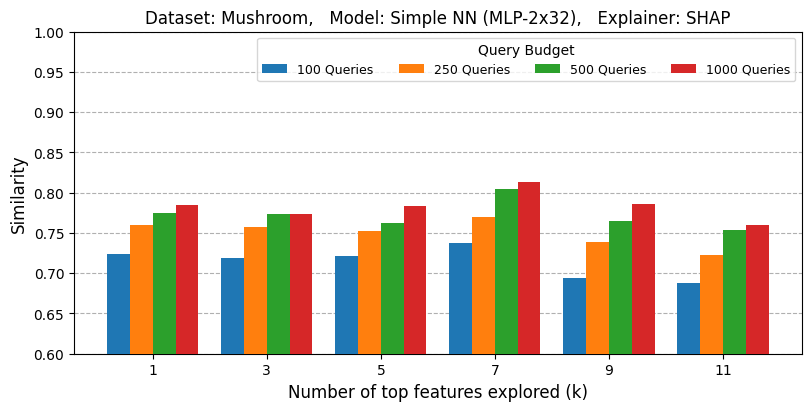

In [20]:
# ---- Cell 6: Plot ----
k = len(nfe)
q = len(query_limit)

# Organize similarity data for bar plot
data_s = [[] for _ in range(q)]
for i in range(k):
    for qi in range(q):
        data_s[qi].append(rtest_sims[q * i + qi])

# Average across sample sets and round
data_s = [list(np.around(np.mean(ds, axis=1), 4)) for ds in data_s]
n_features = [str(x) for x in nfe]
d0 = {f"{query_limit[i]} Queries": data_s[i] for i in range(q)}
x = np.arange(len(n_features)); width = 0.2

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
plt.title('Dataset: ' + dataset_dict.get(which_dataset) +
          ',   Model: ' + model_dict.get(which_model) +
          ',   Explainer: ' + exp_dict.get(explanation_tool), color='black')

mult = 0
for label, values in d0.items():
    offset = width * mult
    ax.bar(x + offset - 0.1, values, width, label=label, zorder=3)
    mult += 1

ax.yaxis.grid(linestyle='--', zorder=0)
ax.set_xlabel('Number of top features explored (k)', fontsize=12)
ax.set_xticks(x + width, n_features)
ax.legend(title='Query Budget', loc='upper right', ncols=4, fontsize=9)
ax.set_ylabel('Similarity', fontsize=12)
ax.set_ylim(0.6, 1.0)
plt.show()


In [21]:
# ---- Cell 1: Imports & Config ----
from pathlib import Path
import re
import numpy as np
from matplotlib import pyplot as plt

NUM_HIDDEN_LAYERS = 2
UNITS_PER_LAYER   = 32
TARGET_DATASET    = "iris"     # ← Iris dataset (ID 0)


In [22]:
# ---- Cell 2: Patch utils.py ----
UTILS_PATH = Path("utils.py")
if not UTILS_PATH.exists():
    raise FileNotFoundError(f"Could not find {UTILS_PATH.resolve()}")

src = UTILS_PATH.read_text(encoding="utf-8")
backup = UTILS_PATH.with_suffix(".py.bak")
backup.write_text(src, encoding="utf-8")

modified = src

# 2.1) Ensure DecisionTreeClassifier import (needed by guard)
if "from sklearn.tree import DecisionTreeClassifier" not in modified:
    m = re.search(r"(^from\s+sklearn[^\n]*\n)", modified, flags=re.MULTILINE)
    insert_line = "from sklearn.tree import DecisionTreeClassifier\n"
    modified = (modified[:m.end()] + insert_line + modified[m.end():]) if m else (insert_line + modified)

# 2.2) Insert/replace which_model == 6 block in load_model(...)
mlp_block = (
    "\n    elif which_model == 6:\n"
    "        from sklearn.pipeline import Pipeline\n"
    "        from sklearn.preprocessing import StandardScaler\n"
    "        from sklearn.neural_network import MLPClassifier\n"
    f"        _hidden = ({','.join([str(UNITS_PER_LAYER)]*NUM_HIDDEN_LAYERS)})\n"
    "        t_model = Pipeline([\n"
    "            (\"scaler\", StandardScaler(with_mean=True, with_std=True)),\n"
    "            (\"mlp\", MLPClassifier(\n"
    "                hidden_layer_sizes=_hidden,\n"
    "                activation=\"relu\",\n"
    "                solver=\"adam\",\n"
    "                alpha=1e-4,\n"
    "                learning_rate_init=1e-3,\n"
    "                max_iter=400,\n"
    "                random_state=0,\n"
    "                verbose=False\n"
    "            ))\n"
    "        ])\n"
    "        t_model.fit(X_train, y_train)\n"
    "        model_name = f'Simple NN (MLP-{len(_hidden)}x{_hidden[0]})'\n"
)

pattern = re.compile(r"def\s+load_model\(\s*which_model\s*,\s*X_train\s*,\s*y_train\s*\):(.*?)(\n\s*return\s+[^;\n]+)", re.S)
m = pattern.search(modified)
if m:
    body = m.group(1)
    if "which_model == 6" in body:
        body = re.sub(r"\n\s*elif\s+which_model\s*==\s*6:[\s\S]*?(?=\n\s*elif|\n\s*return|\Z)", mlp_block, body)
    else:
        body = body + mlp_block
    modified = modified[:m.start(1)] + body + modified[m.end(1):]
else:
    print("WARNING: load_model(...) pattern not found; if id 6 fails, show the load_model signature.")

# 2.3) Guard every s_model.fit(...) (avoid UnboundLocalError)
def _inject_guard_block(match):
    full_line = match.group(0)
    indent = re.match(r"^(\s*)", full_line).group(1)
    guard = (
        f"{indent}# Ensure s_model exists (fallback surrogate)\n"
        f"{indent}try:\n"
        f"{indent}    s_model\n"
        f"{indent}except (UnboundLocalError, NameError):\n"
        f"{indent}    from sklearn.tree import DecisionTreeClassifier\n"
        f"{indent}    s_model = DecisionTreeClassifier(random_state=0)\n"
        f"{indent}s_model.fit("
    )
    return re.sub(r"^\s*s_model\.fit\(", guard, full_line)

modified = re.sub(r"^[ \t]*s_model\.fit\(", _inject_guard_block, modified, flags=re.MULTILINE)

# 2.4) Write back
if modified != src:
    UTILS_PATH.write_text(modified, encoding="utf-8")
    print(f"Patched utils.py. Backup at {backup.name}.")
else:
    print("No changes made (already patched or patterns not found).")


Patched utils.py. Backup at utils.py.bak.


In [23]:
# ---- Cell 3: Load helpers & pick dataset ----
from utils import run_attack_auto, load_experiment_dicts
import importlib, utils
importlib.reload(utils)
from utils import run_attack_auto, load_experiment_dicts

# Label for model id 6
try:
    _orig_load_dicts = load_experiment_dicts
    def _load_experiment_dicts_patched():
        ds, md, ex = _orig_load_dicts()
        md = dict(md)
        md[6] = f"Simple NN (MLP-{NUM_HIDDEN_LAYERS}x{UNITS_PER_LAYER})"
        return ds, md, ex
    globals()['load_experiment_dicts'] = _load_experiment_dicts_patched
except Exception:
    pass

dataset_dict, model_dict, exp_dict = load_experiment_dicts()
print("Datasets available:", dataset_dict)

def choose_dataset_id(ds_dict, target):
    if isinstance(target, int): return target
    t = str(target).lower()
    for i, name in ds_dict.items():
        if t in str(name).lower(): return i
    raise ValueError(f"Could not match dataset '{target}'. Options: {ds_dict}")

which_dataset = choose_dataset_id(dataset_dict, TARGET_DATASET)  # "iris"
which_model   = 6
explanation_tool = 1  # ← SHAP this time
print(f"Selected dataset id {which_dataset} → {dataset_dict.get(which_dataset)} (Explainer = SHAP)")


Datasets available: {0: 'Iris', 1: 'Crop', 2: 'Adult Income', 3: 'Breast Cancer', 4: 'Nursery', 5: 'Mushroom'}
Selected dataset id 0 → Iris (Explainer = SHAP)


In [24]:
# ---- Cell 4: Sanity run ----
how_many_sets    = 1
sample_set_sizes = [1]
nfe              = [1]
query_limit      = [50]

print("\nRunning sanity (Iris + SHAP)...")
res = run_attack_auto(
    which_dataset, which_model, explanation_tool,
    how_many_sets, sample_set_sizes, nfe, query_limit, False
)
accuracies, rtest_sims, samples_mega, other_args = res
print("Sanity OK. len(rtest_sims) =", len(rtest_sims))



Running sanity (Iris + SHAP)...
Train results
[[36  0  0]
 [ 0 37  0]
 [ 0  0 39]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        39

    accuracy                           1.00       112
   macro avg       1.00      1.00      1.00       112
weighted avg       1.00      1.00      1.00       112

Test results
[[9 1 0]
 [0 5 0]
 [0 0 7]]
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.83      1.00      0.91         5
           2       1.00      1.00      1.00         7

    accuracy                           0.95        22
   macro avg       0.94      0.97      0.95        22
weighted avg       0.96      0.95      0.96        22

Model test accuracy:  0.9545 



Dataset:   Iris
ML Model:  Simple NN (MLP-2x32)
SHAP is the explanation tool currently in use

Lower bounds:  [9]  Upper bounds:  [57] (per class for both)

-----The attack starts here!-----

Number of top features allowed to be explored (k): 1

Number of samples per class (n): 1
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
Sample set 0 , n_queries = 6 , Top similarity = 0.1818
Accuracy:  [0.1818] 
Similarity:  [0.1818] 

Sanity OK. len(rtest_sims) = 1


In [25]:
# ---- Full run on Iris dataset ----
which_model      = 6
explanation_tool = 1       # SHAP
how_many_sets    = 10
sample_set_sizes = [3]
nfe              = [1,3,5,7,9,11]
query_limit      = [100,250,500,1000]

print("Running full Iris config (SHAP)...")
accuracies, rtest_sims, samples_mega, other_args = run_attack_auto(
    which_dataset, which_model, explanation_tool,
    how_many_sets, sample_set_sizes, nfe, query_limit, False
)
print("Full run completed! len(rtest_sims) =", len(rtest_sims))


Running full Iris config (SHAP)...
Train results
[[40  0  0]
 [ 0 35  1]
 [ 0  0 36]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      0.97      0.99        36
           2       0.97      1.00      0.99        36

    accuracy                           0.99       112
   macro avg       0.99      0.99      0.99       112
weighted avg       0.99      0.99      0.99       112

Test results
[[6 0 0]
 [0 7 0]
 [0 1 8]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.88      1.00      0.93         7
           2       1.00      0.89      0.94         9

    accuracy                           0.95        22
   macro avg       0.96      0.96      0.96        22
weighted avg       0.96      0.95      0.95        22

Model test accuracy:  0.9545 



Dataset:   Iris
ML Model:  Simple NN (MLP-2x32)
SHAP is the explanation tool currently in use

Lower bounds:  [17, 42, 84, 167]  Upper bounds:  [116, 291, 582, 1166] (per class for both)

-----The attack starts here!-----

Number of top features allowed to be explored (k): 1

Number of samples per class (n): 3
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
Sample set 0 , n_queries = 18 , Top similarity = 0.9091
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
Sample set 1 , n_queries = 18 , Top similarity = 0.9091
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
Sample set 2 , n_queries = 18 , Top similarity = 0.6818
No such model!
No such model!
No such model!
No such model!
No such mo

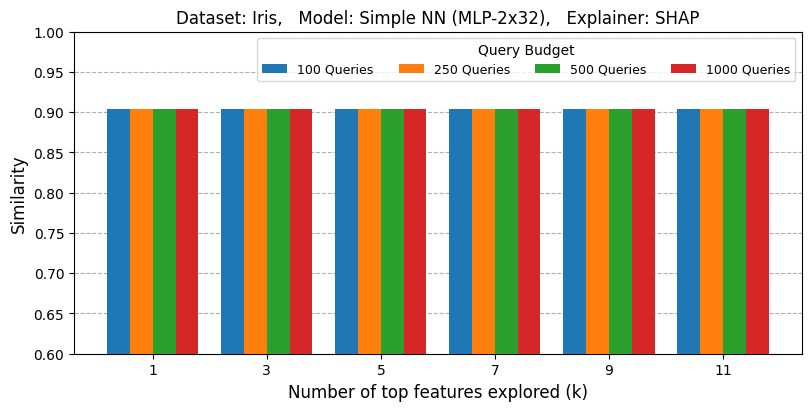

In [26]:
# ---- Cell 6: Plot ----
k = len(nfe)
q = len(query_limit)

# Organize similarity data for bar plot
data_s = [[] for _ in range(q)]
for i in range(k):
    for qi in range(q):
        data_s[qi].append(rtest_sims[q * i + qi])

# Average across sample sets and round
data_s = [list(np.around(np.mean(ds, axis=1), 4)) for ds in data_s]
n_features = [str(x) for x in nfe]
d0 = {f"{query_limit[i]} Queries": data_s[i] for i in range(q)}
x = np.arange(len(n_features)); width = 0.2

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
plt.title('Dataset: ' + dataset_dict.get(which_dataset) +
          ',   Model: ' + model_dict.get(which_model) +
          ',   Explainer: ' + exp_dict.get(explanation_tool), color='black')

mult = 0
for label, values in d0.items():
    offset = width * mult
    ax.bar(x + offset - 0.1, values, width, label=label, zorder=3)
    mult += 1

ax.yaxis.grid(linestyle='--', zorder=0)
ax.set_xlabel('Number of top features explored (k)', fontsize=12)
ax.set_xticks(x + width, n_features)
ax.legend(title='Query Budget', loc='upper right', ncols=4, fontsize=9)
ax.set_ylabel('Similarity', fontsize=12)
ax.set_ylim(0.6, 1.0)
plt.show()


In [ ]:
#Crop Recommendation dataset

In [3]:
# ---- Cell 1: Imports & Config ----
from pathlib import Path
import re
import numpy as np
from matplotlib import pyplot as plt

NUM_HIDDEN_LAYERS = 2
UNITS_PER_LAYER   = 32
TARGET_DATASET    = "crop"      # Dataset name for ID = 1


In [4]:
# ---- Cell 2: Patch utils.py ----
UTILS_PATH = Path("utils.py")
if not UTILS_PATH.exists():
    raise FileNotFoundError(f"Could not find {UTILS_PATH.resolve()}")

src = UTILS_PATH.read_text(encoding="utf-8")
backup = UTILS_PATH.with_suffix(".py.bak")
backup.write_text(src, encoding="utf-8")

modified = src

# 2.1) Ensure DecisionTreeClassifier import (needed by guard)
if "from sklearn.tree import DecisionTreeClassifier" not in modified:
    m = re.search(r"(^from\s+sklearn[^\n]*\n)", modified, flags=re.MULTILINE)
    insert_line = "from sklearn.tree import DecisionTreeClassifier\n"
    modified = (modified[:m.end()] + insert_line + modified[m.end():]) if m else (insert_line + modified)

# 2.2) Insert/replace which_model == 6 block in load_model(...)
mlp_block = (
    "\n    elif which_model == 6:\n"
    "        from sklearn.pipeline import Pipeline\n"
    "        from sklearn.preprocessing import StandardScaler\n"
    "        from sklearn.neural_network import MLPClassifier\n"
    f"        _hidden = ({','.join([str(UNITS_PER_LAYER)]*NUM_HIDDEN_LAYERS)})\n"
    "        t_model = Pipeline([\n"
    "            (\"scaler\", StandardScaler(with_mean=True, with_std=True)),\n"
    "            (\"mlp\", MLPClassifier(\n"
    "                hidden_layer_sizes=_hidden,\n"
    "                activation=\"relu\",\n"
    "                solver=\"adam\",\n"
    "                alpha=1e-4,\n"
    "                learning_rate_init=1e-3,\n"
    "                max_iter=400,\n"
    "                random_state=0,\n"
    "                verbose=False\n"
    "            ))\n"
    "        ])\n"
    "        t_model.fit(X_train, y_train)\n"
    "        model_name = f'Simple NN (MLP-{len(_hidden)}x{_hidden[0]})'\n"
)

pattern = re.compile(r"def\s+load_model\(\s*which_model\s*,\s*X_train\s*,\s*y_train\s*\):(.*?)(\n\s*return\s+[^;\n]+)", re.S)
m = pattern.search(modified)
if m:
    body = m.group(1)
    if "which_model == 6" in body:
        body = re.sub(r"\n\s*elif\s+which_model\s*==\s*6:[\s\S]*?(?=\n\s*elif|\n\s*return|\Z)", mlp_block, body)
    else:
        body = body + mlp_block
    modified = modified[:m.start(1)] + body + modified[m.end(1):]
else:
    print("WARNING: load_model(...) pattern not found; if id 6 fails, show the load_model signature.")

# 2.3) Guard every s_model.fit(...) (avoid UnboundLocalError)
def _inject_guard_block(match):
    full_line = match.group(0)
    indent = re.match(r"^(\s*)", full_line).group(1)
    guard = (
        f"{indent}# Ensure s_model exists (fallback surrogate)\n"
        f"{indent}try:\n"
        f"{indent}    s_model\n"
        f"{indent}except (UnboundLocalError, NameError):\n"
        f"{indent}    from sklearn.tree import DecisionTreeClassifier\n"
        f"{indent}    s_model = DecisionTreeClassifier(random_state=0)\n"
        f"{indent}s_model.fit("
    )
    return re.sub(r"^\s*s_model\.fit\(", guard, full_line)

modified = re.sub(r"^[ \t]*s_model\.fit\(", _inject_guard_block, modified, flags=re.MULTILINE)

# 2.4) Write back
if modified != src:
    UTILS_PATH.write_text(modified, encoding="utf-8")
    print(f"Patched utils.py. Backup at {backup.name}.")
else:
    print("No changes made (already patched or patterns not found).")


Patched utils.py. Backup at utils.py.bak.


In [5]:
# ---- Cell 3: Load helpers & pick dataset ----
from utils import run_attack_auto, load_experiment_dicts
import importlib, utils
importlib.reload(utils)
from utils import run_attack_auto, load_experiment_dicts

# Patch model label for MLP-2x32
try:
    _orig_load_dicts = load_experiment_dicts
    def _load_experiment_dicts_patched():
        ds, md, ex = _orig_load_dicts()
        md = dict(md)
        md[6] = f"Simple NN (MLP-{NUM_HIDDEN_LAYERS}x{UNITS_PER_LAYER})"
        return ds, md, ex
    globals()['load_experiment_dicts'] = _load_experiment_dicts_patched
except Exception:
    pass

dataset_dict, model_dict, exp_dict = load_experiment_dicts()
print("Datasets available:", dataset_dict)

def choose_dataset_id(ds_dict, target):
    if isinstance(target, int):
        return target
    t = str(target).lower()
    for i, name in ds_dict.items():
        if t in str(name).lower():
            return i
    raise ValueError(f"Could not match dataset '{target}'. Options: {ds_dict}")

which_dataset = choose_dataset_id(dataset_dict, TARGET_DATASET)  # "crop"
which_model   = 6
explanation_tool = 1  # SHAP
print(f"Selected dataset id {which_dataset} → {dataset_dict.get(which_dataset)} (Explainer = SHAP)")


Datasets available: {0: 'Iris', 1: 'Crop', 2: 'Adult Income', 3: 'Breast Cancer', 4: 'Nursery', 5: 'Mushroom'}
Selected dataset id 1 → Crop (Explainer = SHAP)


In [6]:
# ---- Cell 4: Sanity run ----
how_many_sets    = 1
sample_set_sizes = [1]
nfe              = [1]
query_limit      = [50]

print("\nRunning sanity (Crop + SHAP)...")
res = run_attack_auto(
    which_dataset, which_model, explanation_tool,
    how_many_sets, sample_set_sizes, nfe, query_limit, False
)
accuracies, rtest_sims, samples_mega, other_args = res
print("Sanity OK. len(rtest_sims) =", len(rtest_sims))



Running sanity (Crop + SHAP)...
Train results
[[75  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 75  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 75  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 75  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 75  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 74  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0 75  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 75  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 75  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 75  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 75  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 75  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 75  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 75  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 75  0  0]
 [ 0  0  0  0  0  1  0  0  0  0  0  0  0  0  0 74  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 75]]
              precision    recall 

Dataset:   Crop
ML Model:  Simple NN (MLP-2x32)
SHAP is the explanation tool currently in use

Lower bounds:  [2]  Upper bounds:  [36] (per class for both)

-----The attack starts here!-----

Number of top features allowed to be explored (k): 1

Number of samples per class (n): 1
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
Sample set 0 , n_queries = 67 , Top similarity = 0.2706
Accuracy:  [0.2784] 
Similarity:  [0.2706] 

Sanity OK. len(rtest_sims) = 1


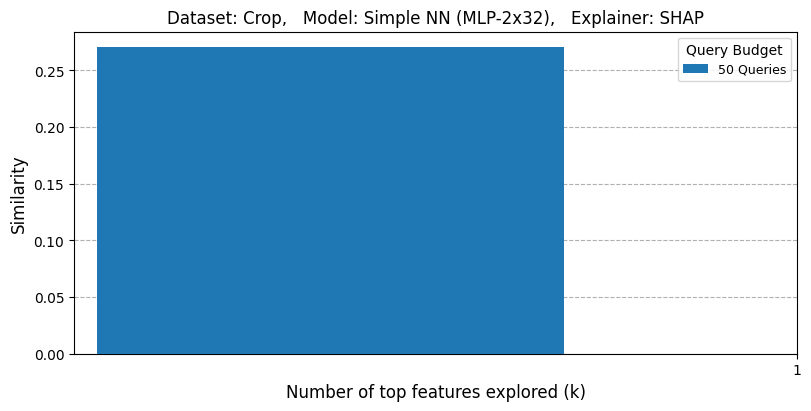

rtest_sims: [[0.2706]]
data_s: [[0.2706]]


In [10]:
# ---- Cell 6: Plot ----
k = len(nfe)
q = len(query_limit)

# Organize similarity data for bar plot
data_s = [[] for _ in range(q)]
for i in range(k):
    for qi in range(q):
        data_s[qi].append(rtest_sims[q * i + qi])

# Average across sample sets and round
data_s = [list(np.around(np.mean(ds, axis=1), 4)) for ds in data_s]
n_features = [str(x) for x in nfe]
d0 = {f"{query_limit[i]} Queries": data_s[i] for i in range(q)}
x = np.arange(len(n_features)); width = 0.2

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
plt.title('Dataset: ' + dataset_dict.get(which_dataset) +
          ',   Model: ' + model_dict.get(which_model) +
          ',   Explainer: ' + exp_dict.get(explanation_tool), color='black')

mult = 0
shift = -0.1 if q > 1 else 0  # only shift groups when we really have multiple bars

for label, values in d0.items():
    offset = width * mult
    ax.bar(x + offset + shift, values, width, label=label, zorder=3)
    mult += 1



ax.yaxis.grid(linestyle='--', zorder=0)
ax.set_xlabel('Number of top features explored (k)', fontsize=12)
ax.set_xticks(x + width, n_features)
ax.legend(title='Query Budget', loc='upper right', ncols=4, fontsize=9)
ax.set_ylabel('Similarity', fontsize=12)
#ax.set_ylim(0.6, 1.0)
plt.show()
print("rtest_sims:", rtest_sims)
print("data_s:", data_s)




In [13]:
how_many_sets    = 5      # or 10 if you can wait
sample_set_sizes = [3]    # 3 samples per class
nfe              = [1, 3, 5, 7]    # more features
query_limit      = [100, 250, 500, 1000] # more queries

print("\nRunning sanity (Crop + SHAP)...")
res = run_attack_auto(
    which_dataset, which_model, explanation_tool,
    how_many_sets, sample_set_sizes, nfe, query_limit, False
)
accuracies, rtest_sims, samples_mega, other_args = res
print("Sanity OK. len(rtest_sims) =", len(rtest_sims))


Running sanity (Crop + SHAP)...
Train results
[[75  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 75  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 75  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 75  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 75  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 74  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0 75  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 75  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 75  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 75  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 75  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 75  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 75  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 75  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 75  0  0]
 [ 0  0  0  0  0  1  0  0  0  0  0  0  0  0  0 74  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 75]]
              precision    recall 

Dataset:   Crop
ML Model:  Simple NN (MLP-2x32)
SHAP is the explanation tool currently in use

Lower bounds:  [3, 8, 15, 30]  Upper bounds:  [88, 246, 508, 1016] (per class for both)

-----The attack starts here!-----

Number of top features allowed to be explored (k): 1

Number of samples per class (n): 3
1 No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
Sample set 0 , n_queries = 151 , Top similarity = 0.6235
1 No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
Sample set 1 , n_queries = 151 , Top similarity = 0.702
1 No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
No such model!
Sample set 2 , n_queries = 151 , Top similarity = 0.6824
1 No such model!
No such model!
No such model!
No such model!
No s

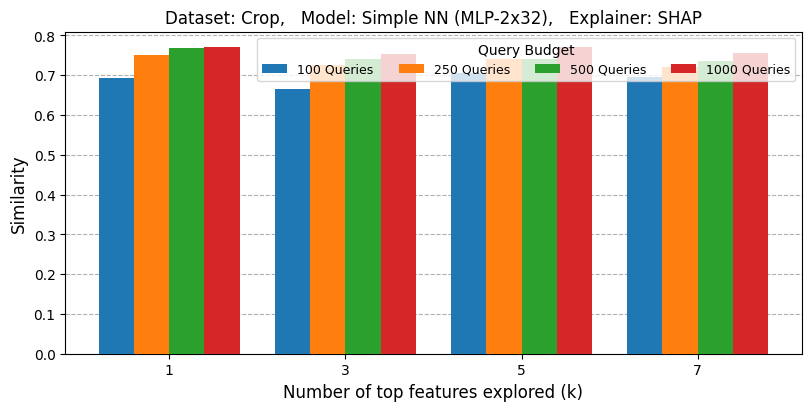

rtest_sims: [[0.6235, 0.702, 0.6824, 0.7059, 0.749], [0.7255, 0.702, 0.7529, 0.7882, 0.7804], [0.7686, 0.7529, 0.7529, 0.7882, 0.7804], [0.7804, 0.7529, 0.7529, 0.7882, 0.7804], [0.6471, 0.6314, 0.6588, 0.7333, 0.651], [0.6471, 0.7294, 0.7373, 0.7804, 0.7333], [0.6471, 0.7294, 0.7922, 0.7804, 0.749], [0.6588, 0.7843, 0.7922, 0.7804, 0.749], [0.702, 0.7373, 0.6745, 0.6784, 0.7373], [0.7608, 0.7373, 0.7529, 0.6784, 0.7686], [0.7608, 0.7373, 0.7529, 0.6784, 0.7686], [0.7686, 0.7961, 0.7529, 0.7686, 0.7686], [0.7255, 0.7451, 0.6235, 0.6784, 0.702], [0.7255, 0.7451, 0.6784, 0.6863, 0.7686], [0.7255, 0.7451, 0.7451, 0.6941, 0.7686], [0.7373, 0.7569, 0.7451, 0.7725, 0.7686]]
data_s: [[0.6926, 0.6643, 0.7059, 0.6949], [0.7498, 0.7255, 0.7396, 0.7208], [0.7686, 0.7396, 0.7396, 0.7357], [0.771, 0.7529, 0.771, 0.7561]]


In [14]:
# ---- Cell 6: Plot ----
k = len(nfe)
q = len(query_limit)

# Organize similarity data for bar plot
data_s = [[] for _ in range(q)]
for i in range(k):
    for qi in range(q):
        data_s[qi].append(rtest_sims[q * i + qi])

# Average across sample sets and round
data_s = [list(np.around(np.mean(ds, axis=1), 4)) for ds in data_s]
n_features = [str(x) for x in nfe]
d0 = {f"{query_limit[i]} Queries": data_s[i] for i in range(q)}
x = np.arange(len(n_features)); width = 0.2

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
plt.title('Dataset: ' + dataset_dict.get(which_dataset) +
          ',   Model: ' + model_dict.get(which_model) +
          ',   Explainer: ' + exp_dict.get(explanation_tool), color='black')

mult = 0
shift = -0.1 if q > 1 else 0  # only shift groups when we really have multiple bars

for label, values in d0.items():
    offset = width * mult
    ax.bar(x + offset + shift, values, width, label=label, zorder=3)
    mult += 1



ax.yaxis.grid(linestyle='--', zorder=0)
ax.set_xlabel('Number of top features explored (k)', fontsize=12)
ax.set_xticks(x + width, n_features)
ax.legend(title='Query Budget', loc='upper right', ncols=4, fontsize=9)
ax.set_ylabel('Similarity', fontsize=12)
#ax.set_ylim(0.6, 1.0)
plt.show()
print("rtest_sims:", rtest_sims)
print("data_s:", data_s)